In [9]:
import pandas as pd
import os

path = "Sales Data"

files = [file for file in os.listdir(path)]

all_data = pd.DataFrame()

for file in files:
    df = pd.read_csv(path + "/" + file)
    all_data = pd.concat([all_data, df])

all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [ ]:

all_data = all_data.dropna()


all_data = all_data[all_data['Order Date'] != 'Order Date']


all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])


all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])

all_data.head()

C:\Users\shuki\AppData\Local\Temp\ipykernel_3684\1231278194.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001"


In [ ]:

all_data['Month'] = all_data['Order Date'].dt.month


all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']


def get_city(address):
    return address.split(',')[1]

all_data['City'] = all_data['Purchase Address'].apply(get_city)

all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles


SALES BY MONTH (TREND)

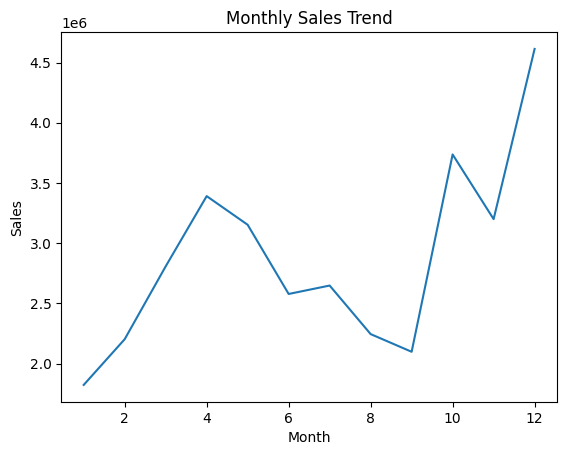

In [12]:
import matplotlib.pyplot as plt

monthly_sales = all_data.groupby('Month')['Sales'].sum()

plt.plot(monthly_sales.index, monthly_sales.values)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Trend')
plt.show()

Sales increase significantly towards the end of the year, peaking in November and December due to holiday season demand.


SALES BY CITY

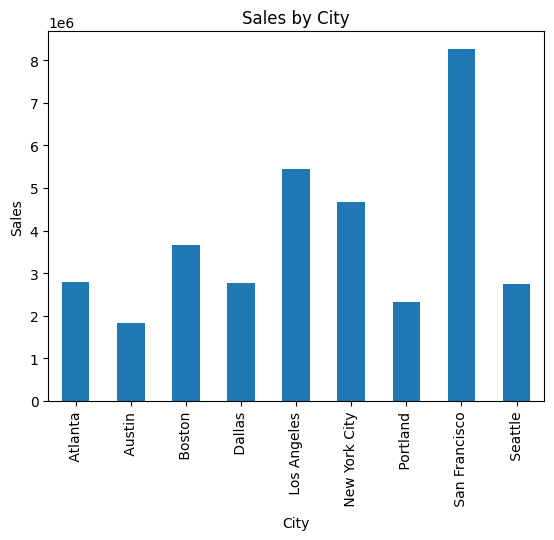

In [13]:
city_sales = all_data.groupby('City')['Sales'].sum()

city_sales.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Sales')
plt.title('Sales by City')
plt.show()

Major cities such as San Francisco, Los Angeles, and New York generate the highest sales, indicating strong demand in urban areas.

TOP PRODUCTS

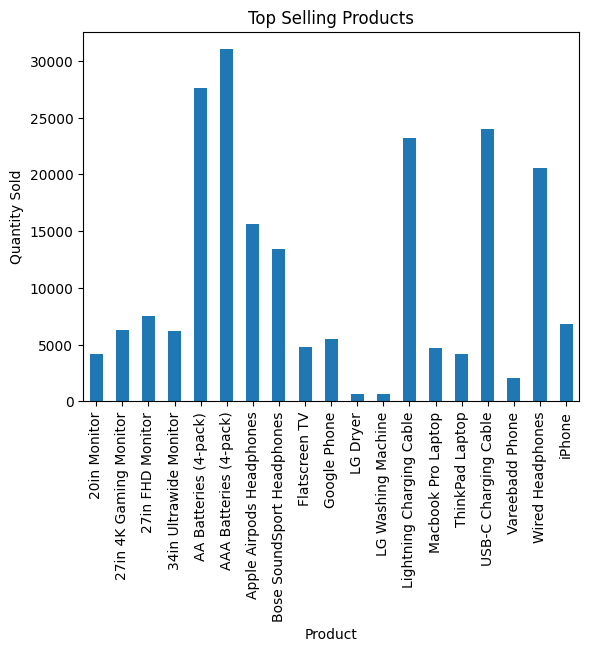

In [14]:
product_sales = all_data.groupby('Product')['Quantity Ordered'].sum()

product_sales.plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.title('Top Selling Products')
plt.show()

Smartphones and accessories are the most frequently purchased products, showing strong consumer demand for electronic devices.

PRICE VS DEMAND

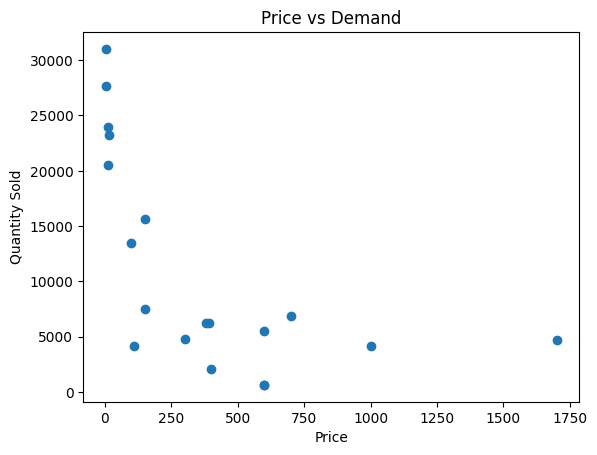

In [15]:
prices = all_data.groupby('Product')['Price Each'].mean()
quantity = all_data.groupby('Product')['Quantity Ordered'].sum()

plt.scatter(prices, quantity)

plt.xlabel('Price')
plt.ylabel('Quantity Sold')
plt.title('Price vs Demand')

plt.show()

Lower-priced products tend to have higher sales volume, while higher-priced products generate significant revenue despite lower quantities.
The strong demand for consumer electronics such as smartphones and laptops directly increases the need for semiconductor components, particularly memory chips (DRAM and NAND), which are essential for data processing and storage.

This seasonal surge in electronics demand implies increased demand for semiconductor components, particularly memory chips used in consumer devices.